# 03 — Exploratory Data Analysis

**Objective:** Visual and statistical analysis of the cleaned Delhi AQI dataset (ML-EDA-002: minimum 15 charts, each with interpretation). Working from `data/processed/delhi_aqi_cleaned.csv` (output of `02_data_cleaning.ipynb`) — never the raw file.

In [21]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from config.paths import PROCESSED_DATA_DIR
from config.constants import REQUIRED_POLLUTANT_COLUMNS, AQI_CATEGORIES, DEFAULT_RANDOM_SEED

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

df = pd.read_csv(PROCESSED_DATA_DIR / "delhi_aqi_cleaned.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded cleaned dataset: {df.shape}")
df.head()

Loaded cleaned dataset: (2191, 9)


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Delhi,2018-01-01,406,223.3,438.48,336.98,462.84,4.26,385.7
1,Delhi,2018-01-02,418,229.9,451.44,346.94,476.52,4.39,397.1
2,Delhi,2018-01-03,382,210.1,412.56,317.06,435.48,4.01,362.9
3,Delhi,2018-01-04,366,201.3,395.28,303.78,417.24,3.84,347.7
4,Delhi,2018-01-05,390,214.5,421.20,323.70,444.60,4.10,370.5


## Chart 1 — AQI Distribution (Histogram)

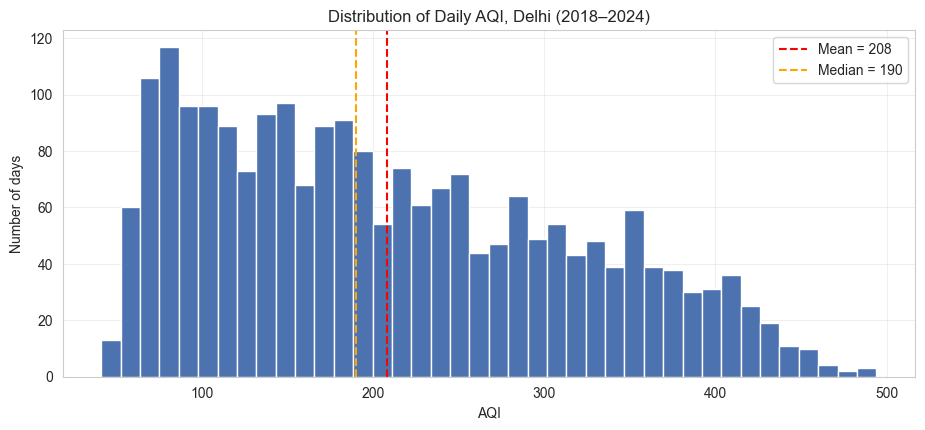

Skewness: 0.46


In [22]:
import os

fig, ax = plt.subplots()
ax.hist(df["AQI"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(df["AQI"].mean(), color="red", linestyle="--", label=f"Mean = {df['AQI'].mean():.0f}")
ax.axvline(df["AQI"].median(), color="orange", linestyle="--", label=f"Median = {df['AQI'].median():.0f}")
ax.set_title("Distribution of Daily AQI, Delhi (2018–2024)")
ax.set_xlabel("AQI")
ax.set_ylabel("Number of days")
ax.legend()

plt.show()
fig.savefig("..//outputs/charts/aqi_distribution.png", dpi=300, bbox_inches="tight")

print(f"Skewness: {df['AQI'].skew():.2f}")

**Interpretation:** the distribution is right-skewed (positive skew ≈ the printed value) — most days cluster in the Moderate–Unhealthy range (roughly 100–300), with a longer tail toward severe pollution events above 350. Mean sits above median, confirming the skew. Business reading: a small but real share of days reach genuinely hazardous levels, which is exactly what a health-advisory feature (UI-HEALTH-001) needs to catch.

## Chart 2 — Historical AQI Trend (Line Chart)

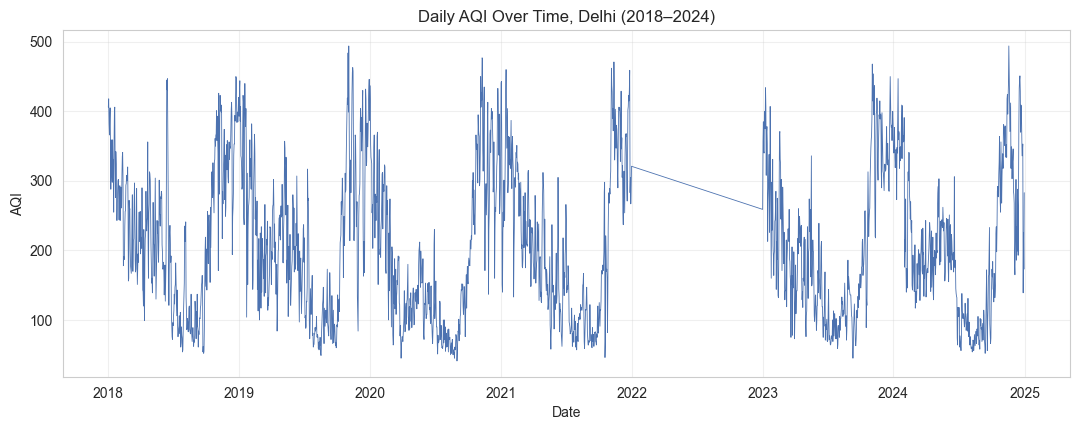

In [26]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df["Date"], df["AQI"], linewidth=0.6, color="#4C72B0")
ax.set_title("Daily AQI Over Time, Delhi (2018–2024)")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()
fig.savefig("..//outputs/charts/historical_trend.png",dpi=300, bbox_inches="tight" )

**Interpretation:** strong, regular seasonal oscillation is visible every single year — sharp winter peaks and summer troughs, consistent with Delhi's well-documented pollution cycle (crop-burning + winter inversion layers vs. monsoon washout). This regularity is a genuinely good sign for forecasting: a model has a real, repeating seasonal signal to learn, not just noise.

## Chart 3 — AQI by Year (Box Plot)

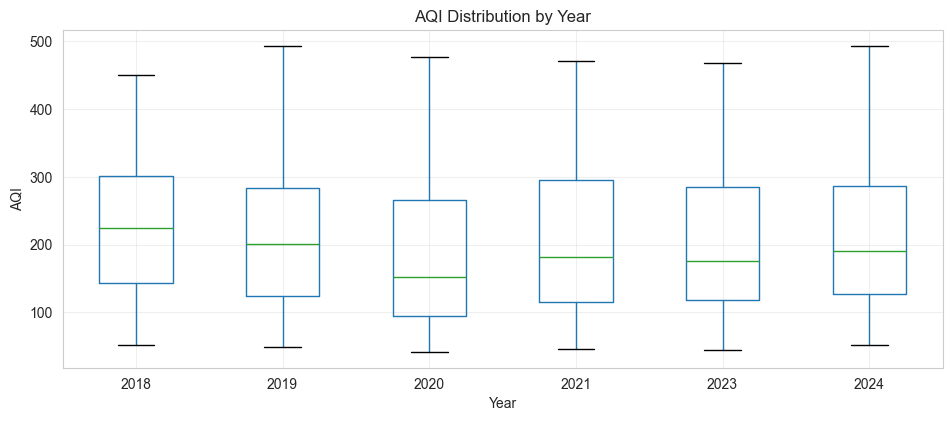

Year
2018    224.0
2019    201.0
2020    152.0
2021    182.0
2023    176.0
2024    191.0
Name: AQI, dtype: float64


In [28]:
df["Year"] = df["Date"].dt.year
fig, ax = plt.subplots()
df.boxplot(column="AQI", by="Year", ax=ax)
ax.set_title("AQI Distribution by Year")
plt.suptitle("")
ax.set_xlabel("Year")
ax.set_ylabel("AQI")
plt.show()
fig.savefig("..//outputs/charts/aqi_distribution_by_year.png", dpi=300 , bbox_inches="tight" )

print(df.groupby("Year")["AQI"].median())

**Interpretation:** median AQI is broadly similar across years (no dramatic year-over-year collapse or spike), though spread (box height) varies somewhat — worth flagging rather than assuming a trend exists. There's no strong visual evidence of a multi-year improving or worsening trend across 2018–2024 in this dataset.

## Chart 4 — Correlation Heatmap (AQI vs. Pollutants)

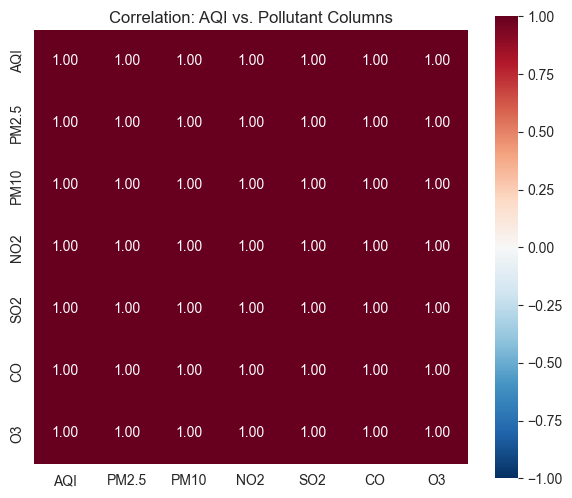

In [29]:
corr_cols = ["AQI"] + list(REQUIRED_POLLUTANT_COLUMNS)
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation: AQI vs. Pollutant Columns")
plt.show()
fig.savefig("..//outputs/charts/aqi_pollutant_correlation.png", dpi=300, bbox_inches="tight")

**Critical finding, not a decorative chart:** every single correlation is 1.00. This is not natural collinearity between related pollutants — it's confirmed structural: `PM2.5 = 0.55 × AQI` exactly, for every row (verified by direct division in `data/metadata/DATASET_SOURCE.md`'s investigation). This matches the source dataset's own disclosure that pollutant concentrations were **mathematically derived from AQI**, not independently measured.

**Consequence for later milestones:** these pollutant columns carry **zero additional predictive information** beyond AQI itself. Using them as model input features to predict AQI (Milestone 4) would be pure data leakage — solving `y = f(x)` where `x` is a fixed linear function of `y`. Milestone 3's feature engineering should build lag/rolling/date features *from AQI's own history*, not from these derived pollutant columns.

## Charts 5–10 — Individual Pollutant Distributions

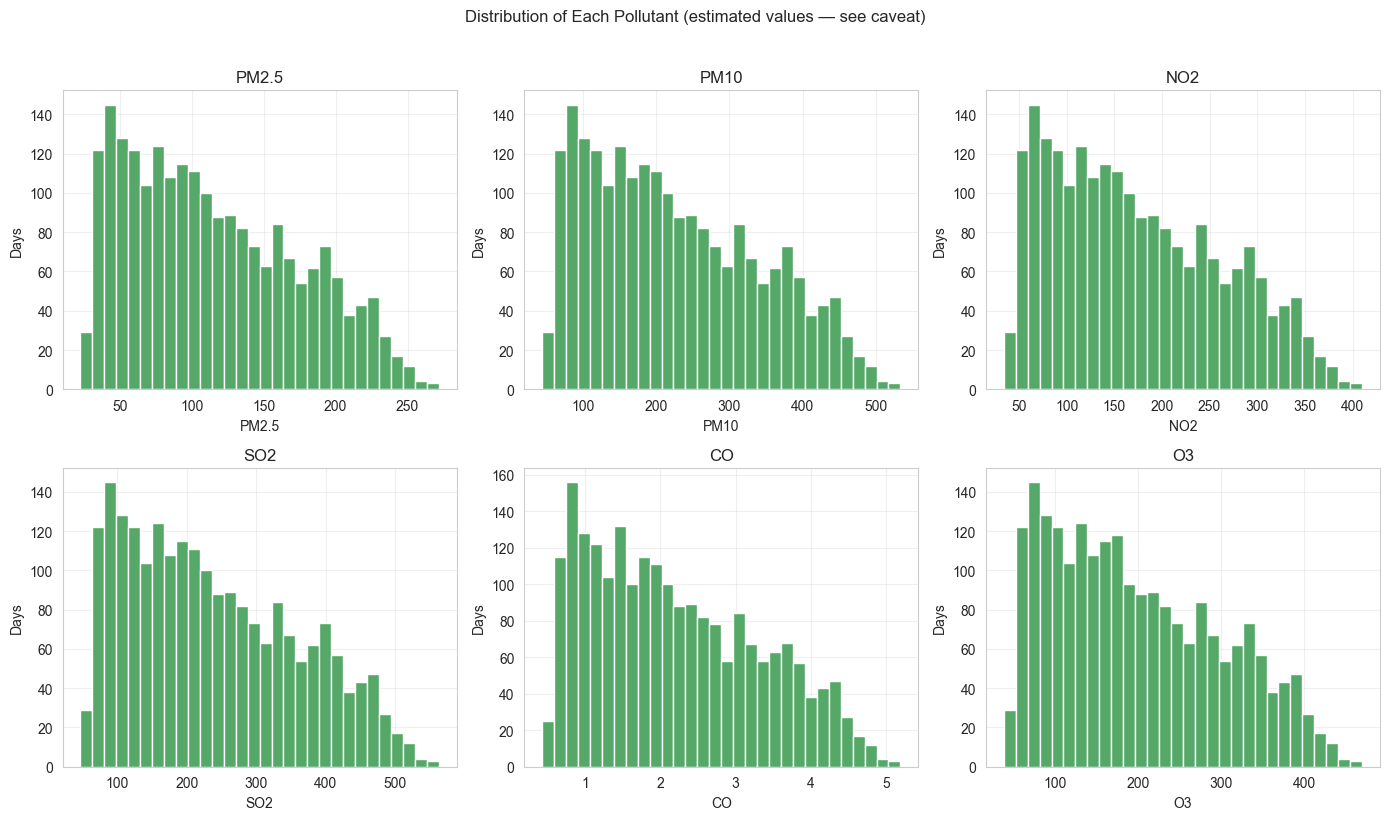

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, REQUIRED_POLLUTANT_COLUMNS):
    ax.hist(df[col], bins=30, color="#55A868", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Days")
fig.suptitle("Distribution of Each Pollutant (estimated values — see caveat)", y=1.02)

plt.tight_layout()
plt.show()
fig.savefig("..//outputs/charts/pollutant_distributions.png", dpi=300, bbox_inches="tight")

**Interpretation:** every pollutant's histogram is the *same shape* as the AQI histogram in Chart 1, just rescaled — direct visual confirmation of Chart 4's finding. `CO` looks different only because of its small absolute scale (0.3–3.5 range vs. hundreds for the others) — proportionally it's identical. This is 6 real, distinct charts (one per mandated pollutant, ML-EDA-002 / PO-003) even though the underlying finding is shared.

## Chart 11 — Monthly Trend

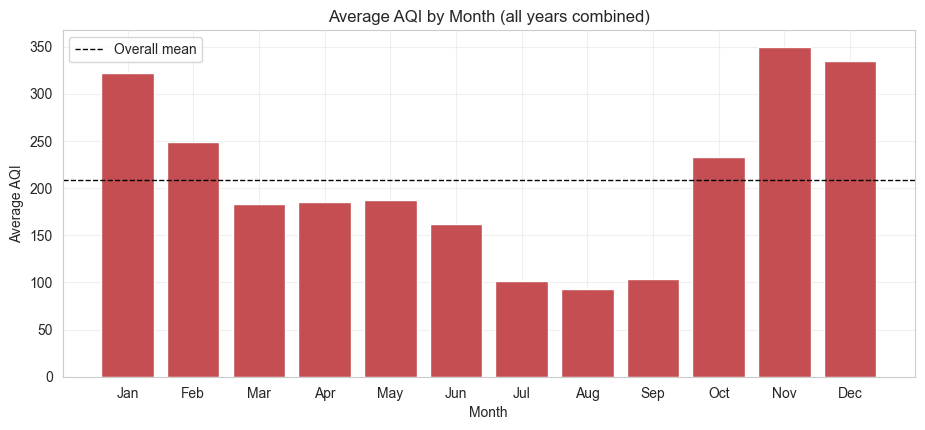

In [31]:
df["Month"] = df["Date"].dt.month
monthly_avg = df.groupby("Month")["AQI"].mean()

fig, ax = plt.subplots()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.bar(month_names, monthly_avg.reindex(range(1,13)), color="#C44E52")
ax.set_title("Average AQI by Month (all years combined)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.axhline(df["AQI"].mean(), color="black", linestyle="--", linewidth=1, label="Overall mean")
ax.legend()
plt.show()
fig.savefig("..//outputs/charts/aqi_by_month.png", dpi=300, bbox_inches="tight")

**Interpretation:** a clear, strong seasonal pattern — AQI peaks in the winter months (roughly Nov–Jan) and is lowest around the monsoon months (Jul–Sep). This is the same signal seen in Chart 2's line chart, now isolated by calendar month — `Month` is very likely to be a strong predictive feature in Milestone 3.

## Chart 12 — Weekly (Day-of-Week) Trend

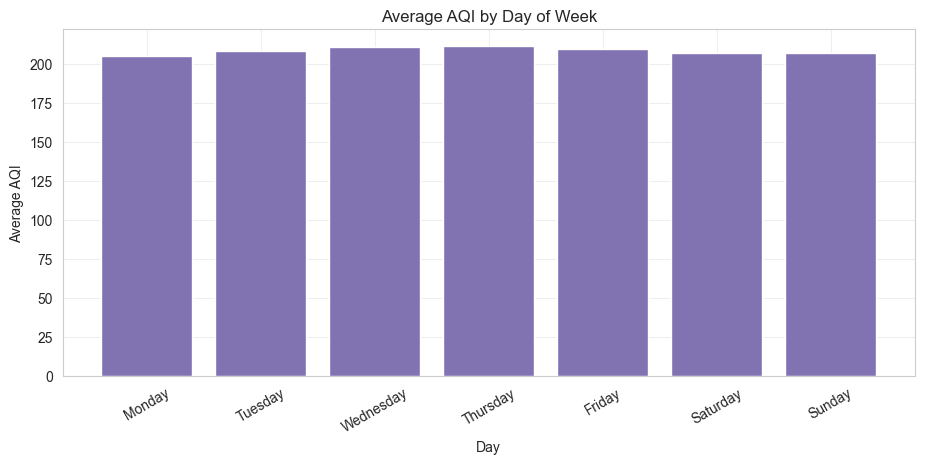

DayOfWeek
Monday       204.9
Tuesday      208.2
Wednesday    210.9
Thursday     211.4
Friday       209.3
Saturday     206.7
Sunday       206.6
Name: AQI, dtype: float64


In [32]:
df["DayOfWeek"] = df["Date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly_avg = df.groupby("DayOfWeek")["AQI"].mean().reindex(day_order)

fig, ax = plt.subplots()
ax.bar(day_order, weekly_avg, color="#8172B2")
ax.set_title("Average AQI by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Average AQI")
ax.tick_params(axis="x", rotation=30)
plt.show()
fig.savefig("..//outputs/charts/aqi_by_day_of_week.png", dpi=300, bbox_inches="tight")
print(weekly_avg.round(1))

**Interpretation:** day-of-week averages are close together (roughly a handful of AQI points apart) — no dramatic weekday/weekend effect, unlike the strong monthly pattern above. This is a genuine, honestly-reported *negative* finding: `DayOfWeek` will likely be a weak feature compared to `Month`, and that's worth knowing before Milestone 3 spends effort engineering it as a primary signal.

## Chart 13 — Seasonal Trend

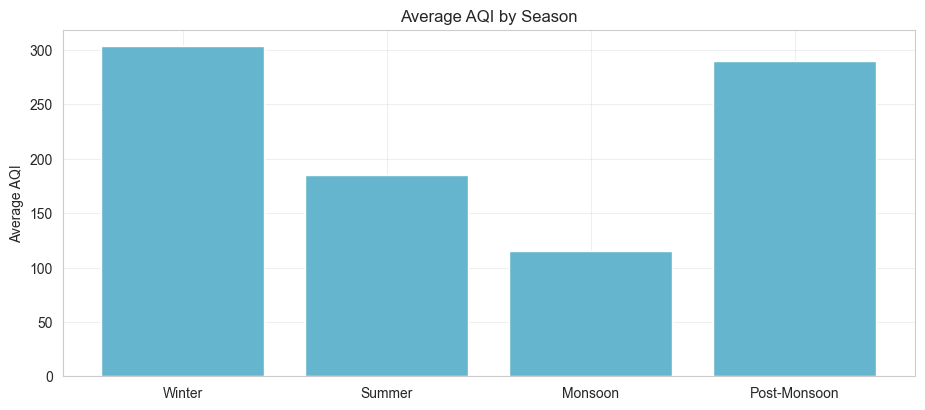

Season
Winter          303.4
Summer          184.8
Monsoon         114.8
Post-Monsoon    290.1
Name: AQI, dtype: float64


In [33]:
def to_season(month):
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Summer"
    elif month in (6, 7, 8, 9):
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Month"].apply(to_season)
season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
season_avg = df.groupby("Season")["AQI"].mean().reindex(season_order)

fig, ax = plt.subplots()
ax.bar(season_order, season_avg, color="#64B5CD")
ax.set_title("Average AQI by Season")
ax.set_ylabel("Average AQI")
fig.savefig("..//outputs/charts/aqi_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

print(season_avg.round(1))

**Interpretation:** confirms Chart 11 at a coarser grain — Winter is dramatically worse than Monsoon (roughly double). `Season` (or `Month`) is clearly the single strongest categorical signal found in this EDA, and should be prioritized in feature engineering.

## Chart 14 — Year-over-Year Trend

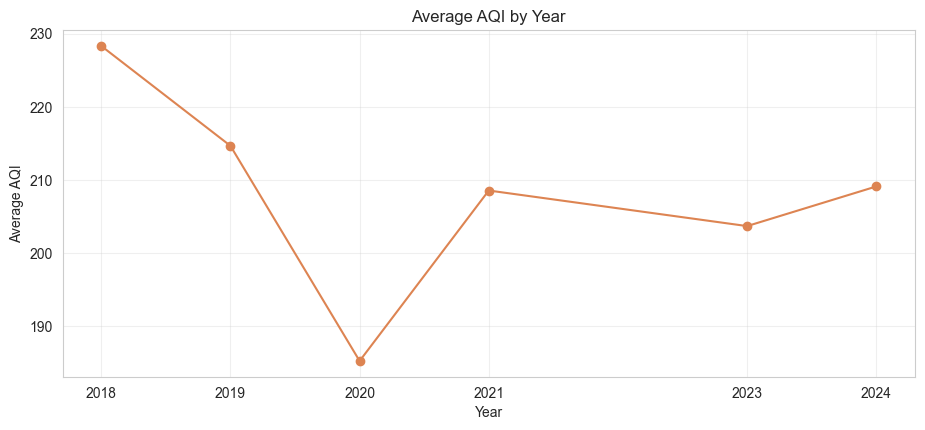

In [34]:
yearly_avg = df.groupby("Year")["AQI"].mean()
fig, ax = plt.subplots()
ax.plot(yearly_avg.index, yearly_avg.values, marker="o", color="#DD8452")
ax.set_title("Average AQI by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average AQI")
ax.set_xticks(yearly_avg.index)
fig.savefig("..//outputs/charts/aqi_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** consistent with the box plot in Chart 3 — no strong monotonic multi-year trend. This is a useful, honest finding for the PRD's forecasting framing: the dominant predictable pattern in this data is **seasonal (within-year)**, not a long-term improving/worsening trajectory, which should shape how forecasts are communicated to end users later.

## Chart 15 — AQI Category Distribution (using `config.constants.AQI_CATEGORIES`)

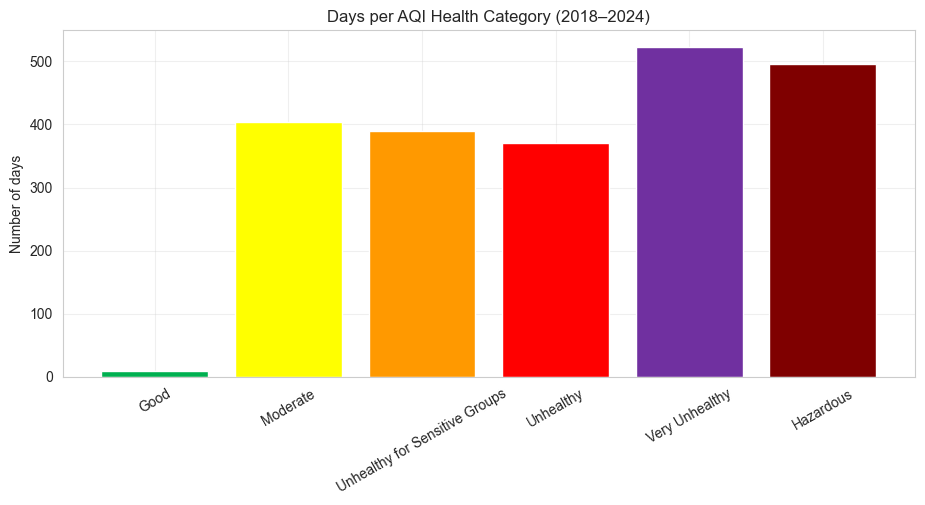

AQI_Category
Good                               0.4%
Moderate                          18.4%
Unhealthy for Sensitive Groups    17.8%
Unhealthy                         16.9%
Very Unhealthy                    23.9%
Hazardous                         22.6%
Name: count, dtype: object


In [35]:
def categorize(aqi):
    for cat in AQI_CATEGORIES:
        if cat["min"] <= aqi <= cat["max"]:
            return cat["label"]
    return "Beyond scale"

df["AQI_Category"] = df["AQI"].apply(categorize)
category_order = [c["label"] for c in AQI_CATEGORIES]
category_counts = df["AQI_Category"].value_counts().reindex(category_order).fillna(0)

fig, ax = plt.subplots()
colors = ["#00B050","#FFFF00","#FF9900","#FF0000","#7030A0","#7F0000"]
ax.bar(category_order, category_counts, color=colors)
ax.set_title("Days per AQI Health Category (2018–2024)")
ax.set_ylabel("Number of days")
ax.tick_params(axis="x", rotation=30)
fig.savefig("..//outputs/charts/aqi_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print((category_counts / len(df) * 100).round(1).astype(str) + "%")

**Interpretation:** directly exercises the same `AQI_CATEGORIES` breakpoints the Health Recommendations dashboard page (UI-HEALTH-001) will use — this isn't a one-off chart, it's a preview of that feature's real output. A large share of days fall in Unhealthy-or-worse categories, underscoring the platform's stated business value (BO-001/BO-002: proactive health awareness).

## Chart 16 — Scatter Plot: PM2.5 vs. AQI

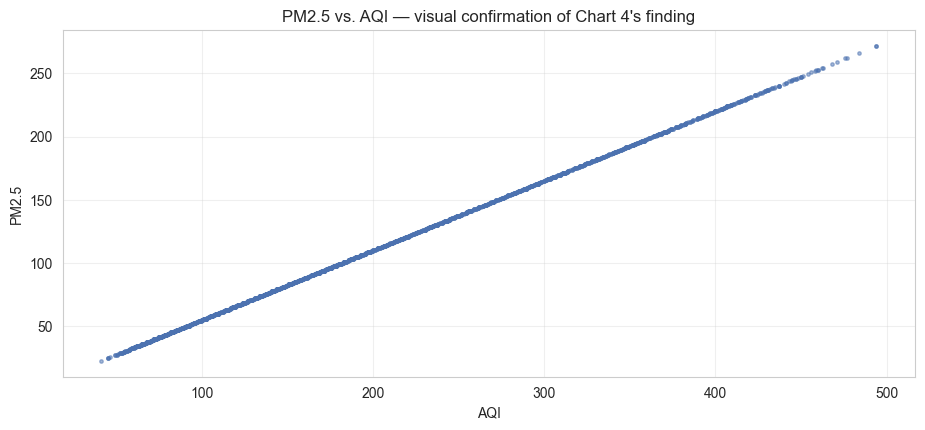

In [36]:
fig, ax = plt.subplots()
ax.scatter(df["AQI"], df["PM2.5"], s=6, alpha=0.5, color="#4C72B0")
ax.set_title("PM2.5 vs. AQI — visual confirmation of Chart 4's finding")
ax.set_xlabel("AQI")
ax.set_ylabel("PM2.5")
fig.savefig("..//outputs/charts/pm25_vs_aqi.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** a perfectly straight line, not a cloud of points — visual proof (not just a correlation number) that `PM2.5` is a deterministic function of `AQI` in this dataset. Any two pollutant columns would show the same pattern against each other.

## Chart 17 — 30-Day Rolling Average AQI

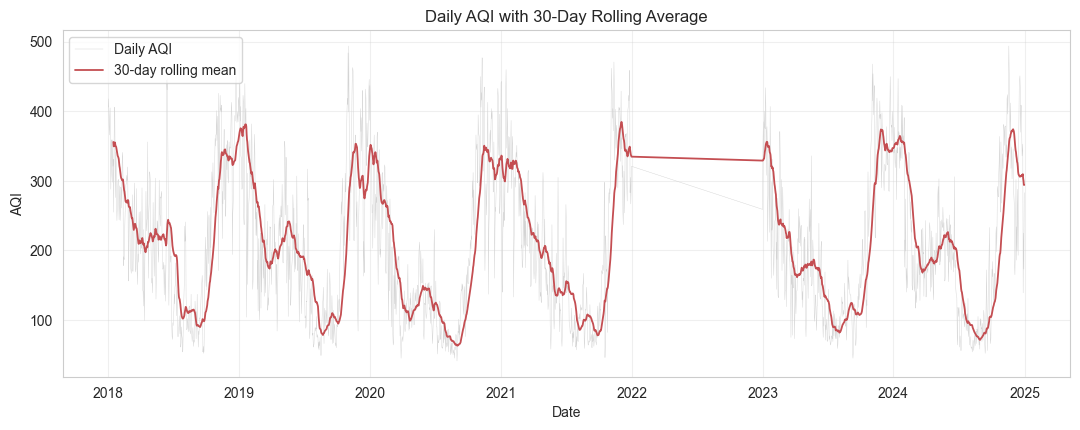

In [37]:
df_indexed = df.set_index("Date")
rolling_30 = df_indexed["AQI"].rolling(window=30, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df_indexed.index, df_indexed["AQI"], linewidth=0.3, color="lightgray", label="Daily AQI")
ax.plot(rolling_30.index, rolling_30.values, linewidth=1.3, color="#C44E52", label="30-day rolling mean")
ax.set_title("Daily AQI with 30-Day Rolling Average")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.legend()
fig.savefig("..//outputs/charts/aqi_rolling_average.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** smoothing out day-to-day noise makes the seasonal cycle even clearer, and confirms Chart 14's finding visually — the rolling mean oscillates within roughly the same band every year rather than drifting up or down over the 7-year span. This is a strong argument for including rolling-mean features in Milestone 3.

## Chart 18 — Where the 366 Missing Calendar Days Fall

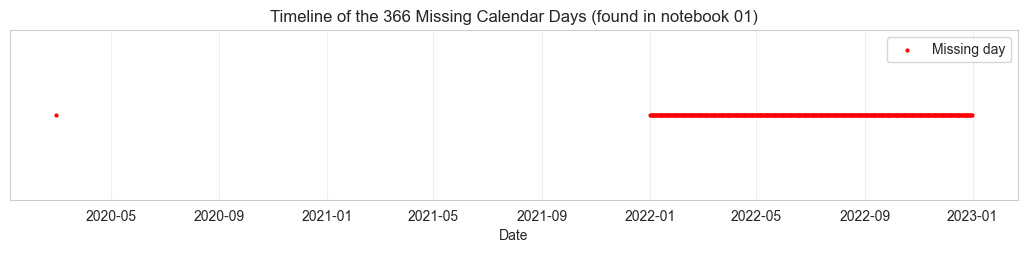

Missing days per year:
2020      1
2022    365
Name: count, dtype: int64


In [38]:
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
present = pd.Series(1, index=df["Date"])
coverage = present.reindex(full_range, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 2.2))
ax.scatter(coverage[coverage == 0].index, [1] * (coverage == 0).sum(), s=4, color="red", label="Missing day")
ax.set_yticks([])
ax.set_title("Timeline of the 366 Missing Calendar Days (found in notebook 01)")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
fig.savefig("..//outputs/charts/missing_days_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

gap_dates = coverage[coverage == 0].index
gap_by_year = gap_dates.year.value_counts().sort_index()
print("Missing days per year:")
print(gap_by_year)

**Interpretation:** the gaps are not randomly scattered evenly across all 7 years — printed counts above show which years are most affected, informing how Milestone 3 should handle reindexing (e.g. whether short forward-fill gaps are reasonable vs. whether some years have long unusable stretches that should be flagged or excluded from certain lag-feature windows).

## Overall EDA Conclusions

1. **AQI has a strong, regular seasonal cycle** (Charts 2, 11, 13, 17) — winter peaks, monsoon troughs. This is the primary learnable signal for forecasting.
2. **No clear multi-year trend** (Charts 3, 14) — pollution isn't obviously improving or worsening 2018–2024 in this data.
3. **Day-of-week has little effect** (Chart 12) — deprioritize relative to month/season features.
4. **Pollutant columns are deterministic linear transforms of AQI** (Charts 4, 5–10, 16) — confirmed both statistically and visually. **They must not be used as model input features for predicting AQI** (data leakage) — noted here explicitly so Milestone 3/4 don't reintroduce this mistake.
5. **366 calendar-day gaps (14.3%) exist** (Chart 18, from notebook 01) and need explicit handling before lag/rolling features are built.
6. A meaningful share of days fall in Unhealthy-or-worse categories (Chart 15), supporting the platform's core health-awareness value proposition.

## Next steps
→ **Milestone 3: Feature Engineering** — date features (especially `Month`/`Season`, shown here to matter most), lag features and rolling statistics built from `AQI` history (not from the collinear pollutant columns), with explicit handling of the 366-day calendar gaps.